In [1]:
import sys
import os

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from numpy.testing import assert_allclose

from src.ridge_regression import RidgeRegression
from src.lasso_regression import LassoRegression

In [2]:
import numpy as np
from sklearn.linear_model import Ridge
from numpy.testing import assert_allclose
from src.ridge_regression import RidgeRegression

# 1. Generate synthetic data for testing
np.random.seed(42)
X_verify = np.random.rand(100, 5) # 100 samples, 5 features
y_verify = np.random.rand(100)    # 100 target values
lambda_val = 1.0

# 2. Fit your custom Ridge model
custom_ridge = RidgeRegression(lambda_=lambda_val)
custom_ridge.fit(X_verify, y_verify)
custom_preds = custom_ridge.predict(X_verify)

# 3. Fit the scikit-learn Ridge model
# In scikit-learn, the regularization parameter lambda is named 'alpha'.
# We set fit_intercept=True because your custom model appends a column of 1s.
sklearn_ridge = Ridge(alpha=lambda_val, fit_intercept=True)
sklearn_ridge.fit(X_verify, y_verify)
sklearn_preds = sklearn_ridge.predict(X_verify)

# 4. Verification Tests
try:
    # Test 1: Compare predictions
    assert_allclose(custom_preds, sklearn_preds, rtol=1e-9, atol=1e-9)
    print("SUCCESS: Predictions match scikit-learn within 10^-9 tolerance!")
    
    # Test 2: Compare learned weights
    # sklearn stores features weights in .coef_ and the bias in .intercept_
    # Your model stores them together, with the bias at the very end.
    sklearn_weights_combined = np.append(sklearn_ridge.coef_, sklearn_ridge.intercept_)
    
    assert_allclose(custom_ridge.weights, sklearn_weights_combined, rtol=1e-9, atol=1e-9)
    print("SUCCESS: Weights and Intercept match scikit-learn within 10^-9 tolerance!")

except AssertionError as e:
    print("FAILURE: Models do not match within tolerance.")
    print(e)

SUCCESS: Predictions match scikit-learn within 10^-9 tolerance!
SUCCESS: Weights and Intercept match scikit-learn within 10^-9 tolerance!


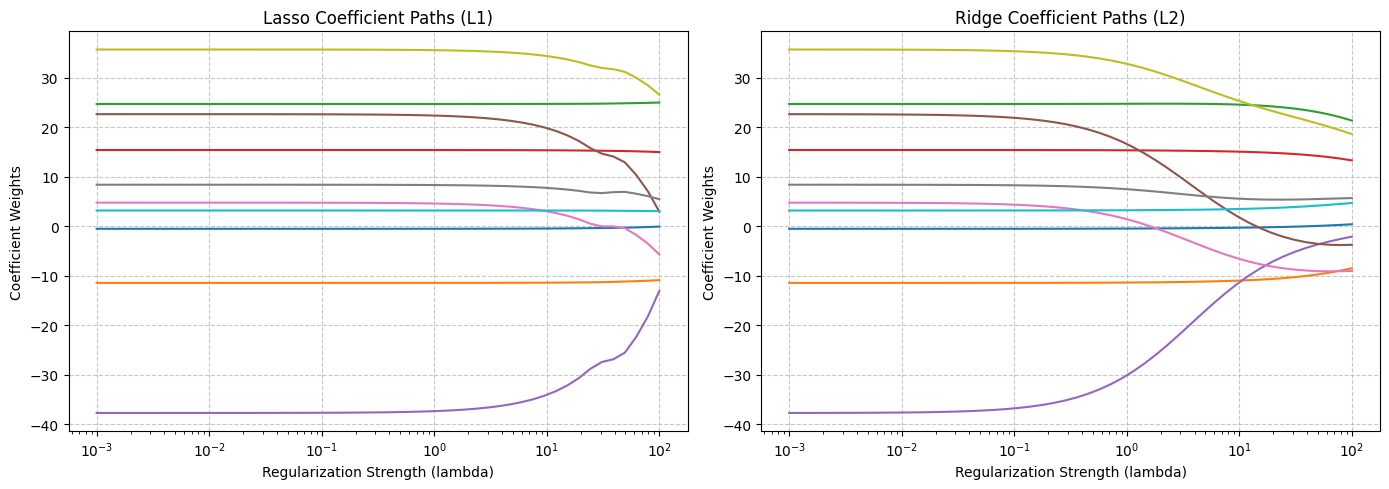

In [3]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from src.lasso_regression import LassoRegression

# 1. Load and Standardize the Diabetes Dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# It is standard practice to standardize X and center y for regularization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_centered = y - np.mean(y)

# 2. Define lambda range: logarithmically spaced between 10^-3 and 10^2
# Using 50 points provides a smooth line for the plot
lambdas = np.logspace(-3, 2, 50)

# 3. Fit models and store weights
lasso_weights = []
ridge_weights = []

for lam in lambdas:
    # Fit Lasso
    lasso_model = LassoRegression(lambda_=lam, max_iter=10000, tol=1e-4)
    lasso_model.fit(X_scaled, y_centered)
    lasso_weights.append(lasso_model.weights.copy())
    
    # Fit Ridge
    ridge_model = RidgeRegression(lambda_=lam)
    ridge_model.fit(X_scaled, y_centered)
    # Note: Your Ridge implementation puts the bias term at the very end of the weights array.
    # We slice with [:-1] to extract only the feature weights for plotting.
    ridge_weights.append(ridge_model.weights[:-1].copy())

lasso_weights = np.array(lasso_weights)
ridge_weights = np.array(ridge_weights)

# 4. Plot the coefficient paths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Lasso Plot
ax1.plot(lambdas, lasso_weights)
ax1.set_xscale('log') # Logarithmic scale for the x-axis
ax1.set_xlabel('Regularization Strength (lambda)')
ax1.set_ylabel('Coefficient Weights')
ax1.set_title('Lasso Coefficient Paths (L1)')
ax1.grid(True, linestyle='--', alpha=0.7)

# Panel 2: Ridge Plot
ax2.plot(lambdas, ridge_weights)
ax2.set_xscale('log') # Logarithmic scale for the x-axis
ax2.set_xlabel('Regularization Strength (lambda)')
ax2.set_ylabel('Coefficient Weights')
ax2.set_title('Ridge Coefficient Paths (L2)')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(
    '../figures/Lasso_Coefficient_Paths_(L1)_and_Ridge_Coefficient_Paths_(L2).pdf',
    format='pdf', 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()


Grid Search Time: 0.8046 seconds | Best Lambda: 29.7635 | Best RMSE: 0.7282
Random Search Time: 0.5499 seconds | Best Lambda: 46.1935 | Best RMSE: 0.7281


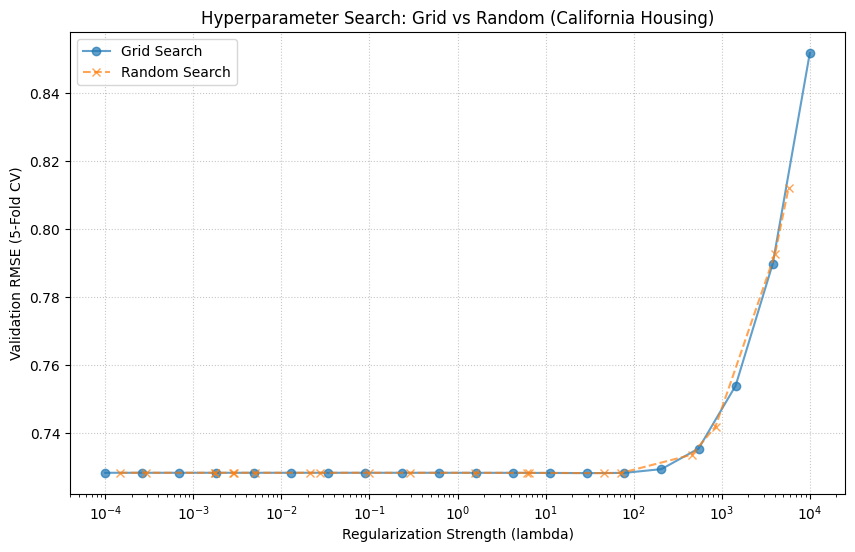

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# 1. Load and standardize the California Housing dataset
california = fetch_california_housing()
X, y = california.data, california.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# We don't need to strictly center y because your RidgeRegression inherently adds an intercept

# 2. Define lambda values
np.random.seed(42) # For reproducibility
grid_lambdas = np.logspace(-4, 4, 20)
random_lambdas = 10 ** np.random.uniform(-4, 4, 20)

# Sort random_lambdas strictly for cleaner plotting later
random_lambdas = np.sort(random_lambdas)

# 3. Setup 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_search_strategy(lambdas, X_data, y_data):
    rmse_scores = []
    
    for lam in lambdas:
        fold_rmses = []
        for train_idx, val_idx in kf.split(X_data):
            X_tr, X_val = X_data[train_idx], X_data[val_idx]
            y_tr, y_val = y_data[train_idx], y_data[val_idx]
            
            model = RidgeRegression(lambda_=lam)
            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)
            
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            fold_rmses.append(rmse)
            
        rmse_scores.append(np.mean(fold_rmses))
    return np.array(rmse_scores)

# --- Evaluate Grid Search ---
start_time = time.time()
grid_rmses = evaluate_search_strategy(grid_lambdas, X_scaled, y)
grid_time = time.time() - start_time

best_grid_idx = np.argmin(grid_rmses)
best_grid_lam = grid_lambdas[best_grid_idx]

# --- Evaluate Random Search ---
start_time = time.time()
random_rmses = evaluate_search_strategy(random_lambdas, X_scaled, y)
random_time = time.time() - start_time

best_random_idx = np.argmin(random_rmses)
best_random_lam = random_lambdas[best_random_idx]

# 4. Reporting
print(f"Grid Search Time: {grid_time:.4f} seconds | Best Lambda: {best_grid_lam:.4f} | Best RMSE: {grid_rmses[best_grid_idx]:.4f}")
print(f"Random Search Time: {random_time:.4f} seconds | Best Lambda: {best_random_lam:.4f} | Best RMSE: {random_rmses[best_random_idx]:.4f}")

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.plot(grid_lambdas, grid_rmses, marker='o', label='Grid Search', linestyle='-', alpha=0.7)
plt.plot(random_lambdas, random_rmses, marker='x', label='Random Search', linestyle='--', alpha=0.7)
plt.xscale('log')
plt.xlabel('Regularization Strength (lambda)')
plt.ylabel('Validation RMSE (5-Fold CV)')
plt.title('Hyperparameter Search: Grid vs Random (California Housing)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('../figures/Hyperparameter_Search_Grid_vs_Random_(California_Housing).pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()


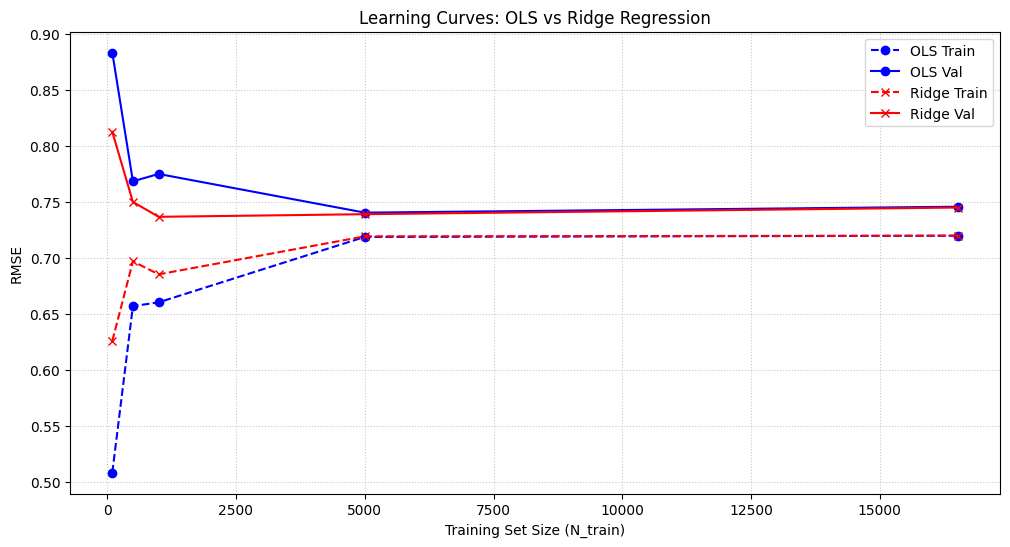

In [5]:
from sklearn.model_selection import train_test_split

# 1. Create a fixed 20% validation set
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 2. Define training sizes and lists to store RMSE
N_train_sizes = [100, 500, 1000, 5000, len(X_train_full)]
best_lambda = best_grid_lam # Using the best lambda found in 4.2.3

ols_train_rmse, ols_val_rmse = [], []
ridge_train_rmse, ridge_val_rmse = [], []

# 3. Train on increasing subsets of data
for n in N_train_sizes:
    # Subset the training data
    X_tr = X_train_full[:n]
    y_tr = y_train_full[:n]
    
    # --- OLS (Ridge with lambda = 0) ---
    ols = RidgeRegression(lambda_=0.0)
    ols.fit(X_tr, y_tr)
    ols_train_rmse.append(np.sqrt(mean_squared_error(y_tr, ols.predict(X_tr))))
    ols_val_rmse.append(np.sqrt(mean_squared_error(y_val, ols.predict(X_val))))
    
    # --- Ridge (with best lambda) ---
    ridge = RidgeRegression(lambda_=best_lambda)
    ridge.fit(X_tr, y_tr)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_tr, ridge.predict(X_tr))))
    ridge_val_rmse.append(np.sqrt(mean_squared_error(y_val, ridge.predict(X_val))))

# 4. Plotting the Learning Curves
plt.figure(figsize=(12, 6))

# Plot OLS Curves
plt.plot(N_train_sizes, ols_train_rmse, marker='o', color='blue', linestyle='--', label='OLS Train')
plt.plot(N_train_sizes, ols_val_rmse, marker='o', color='blue', linestyle='-', label='OLS Val')

# Plot Ridge Curves
plt.plot(N_train_sizes, ridge_train_rmse, marker='x', color='red', linestyle='--', label='Ridge Train')
plt.plot(N_train_sizes, ridge_val_rmse, marker='x', color='red', linestyle='-', label='Ridge Val')

plt.xlabel('Training Set Size (N_train)')
plt.ylabel('RMSE')
plt.title('Learning Curves: OLS vs Ridge Regression')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('../figures/Learning_Curves_OLS_vs_Ridge_Regression.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()